In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from calculate_param_models import calculate_param_models
from calculate_metrics import calculate_metrics
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier


In [2]:
penguins = pd.read_csv('penguins.csv')
penguins

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,NaN,NaN,NaN,NaN,0
4,36.7,19.3,193.0,3450.0,0
...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,2
340,43.5,18.1,202.0,3400.0,2
341,49.6,18.2,193.0,3775.0,2
342,50.8,19.0,210.0,4100.0,2


In [3]:

penguins = penguins.dropna()
X = penguins.drop(columns='Species')
features = X.columns.to_list()
y = penguins['Species']
print(pd.Series(y).value_counts(normalize = True),'\n')
penguins.info()

Species
0    0.441520
1    0.359649
2    0.198830
Name: proportion, dtype: float64 

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        342 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.0 KB


In [4]:
X.describe()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
penguins.isnull().sum()

CulmenLength     0
CulmenDepth      0
FlipperLength    0
BodyMass         0
Species          0
dtype: int64

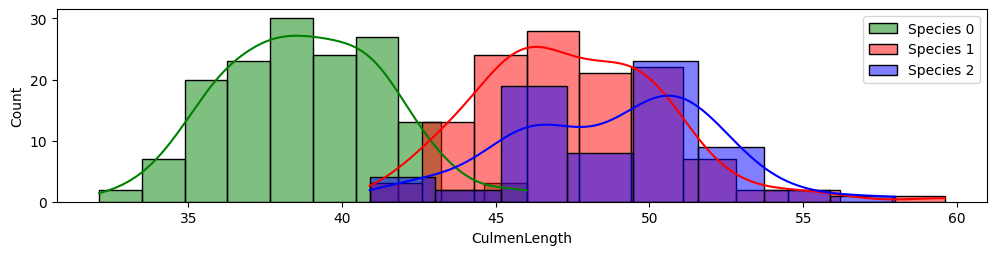

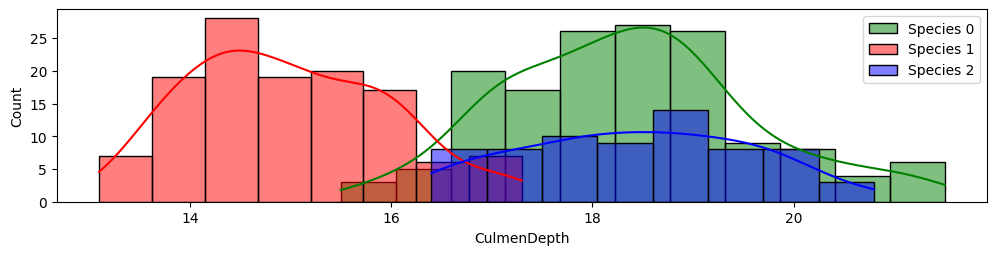

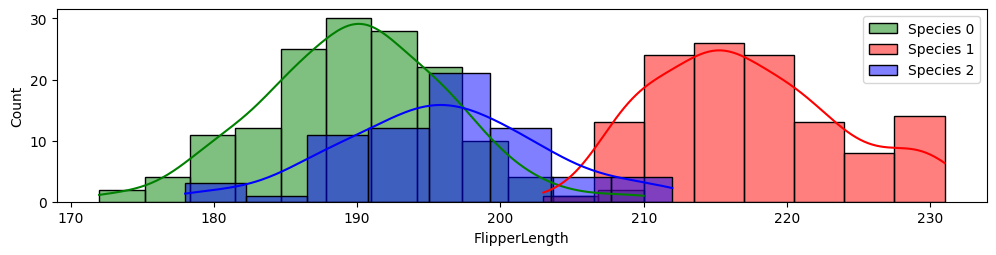

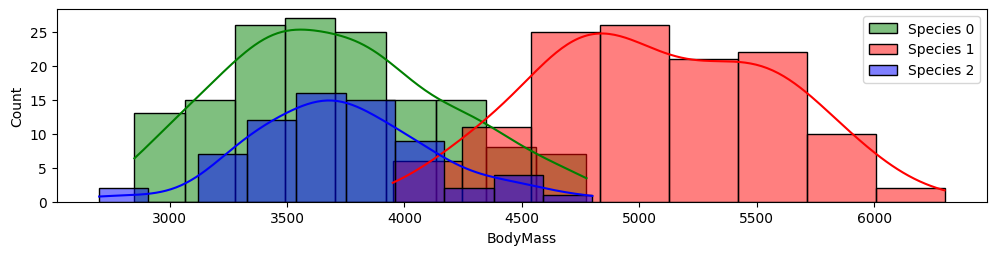

In [6]:
import seaborn as sns
for col in features:
    plt.figure(figsize=(12, 2.5))
    sns.histplot(penguins.loc[penguins['Species']==0, col], kde=True, color='green', label='Species 0')
    sns.histplot(penguins.loc[penguins['Species']==1, col], kde=True, color='red', label='Species 1')
    sns.histplot(penguins.loc[penguins['Species']==2, col], kde=True, color='blue', label='Species 2')
    plt.legend(loc='upper right')
    plt.show()

Tutaj bym się już zatrzymał zbiory są dość dobrze rozdzielone więc jakieś tree powinno sobie poradzić z tym zbiorem. Pewnym problemem mogą okazać się połączenia zbiorów na Culmen oraz nie duża liczba recordów w zbiorze.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print ('Treningowe obserwacje: %d\nTestowe obserwacje: %d' % (X_train.shape[0], X_test.shape[0]))
best_models = calculate_param_models(X_train,y_train)

Treningowe obserwacje: 239
Testowe obserwacje: 103

===== Logistic Regression =====
Fitting 5 folds for each of 5 candidates, totalling 25 fits

===== KNN =====
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== Decision Tree =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== Random Forest =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== SVC =====
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== AdaBoost =====
Fitting 5 folds for each of 9 candidates, totalling 45 fits


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       1.00      1.00      1.00        37
           2       0.95      0.95      0.95        21

    accuracy                           0.98       103
   macro avg       0.98      0.98      0.98       103
weighted avg       0.98      0.98      0.98       103



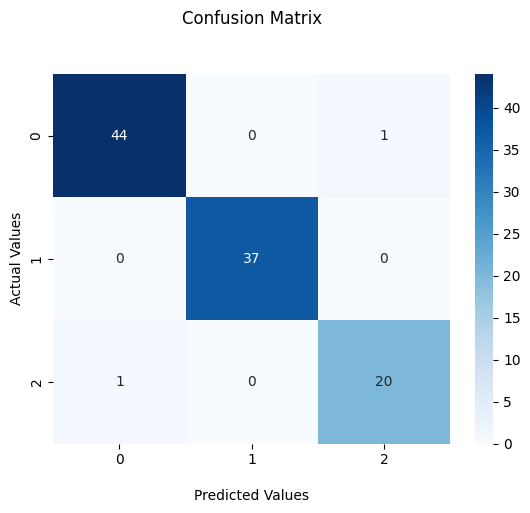

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        45
           1       1.00      0.97      0.99        37
           2       0.90      0.90      0.90        21

    accuracy                           0.95       103
   macro avg       0.95      0.94      0.95       103
weighted avg       0.95      0.95      0.95       103



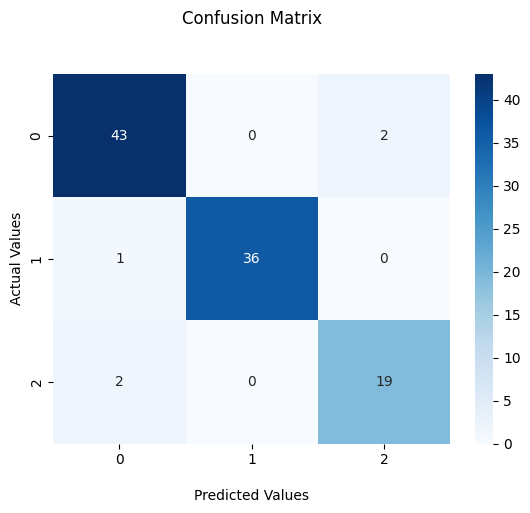

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        45
           1       1.00      1.00      1.00        37
           2       0.95      0.86      0.90        21

    accuracy                           0.96       103
   macro avg       0.96      0.94      0.95       103
weighted avg       0.96      0.96      0.96       103



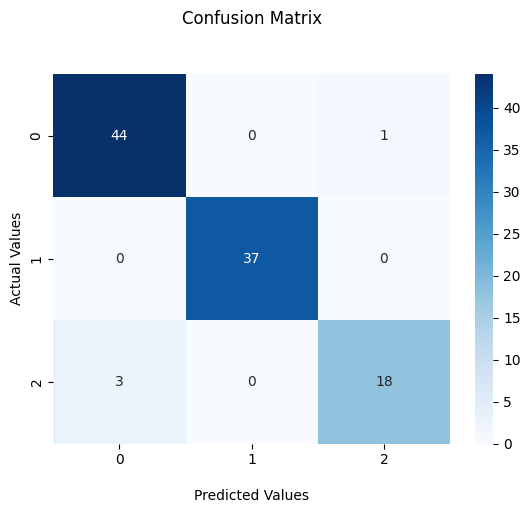

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


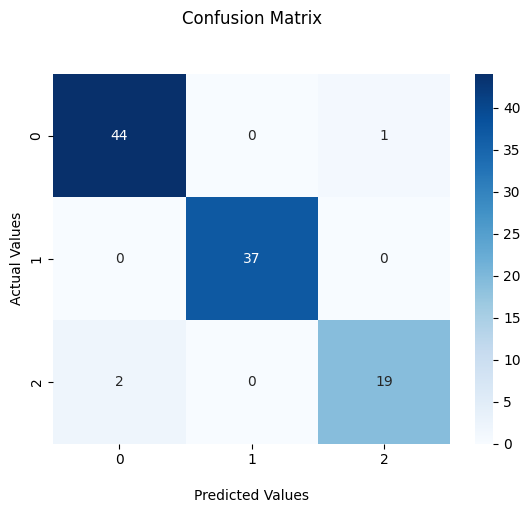

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        45
           1       1.00      1.00      1.00        37
           2       0.95      0.86      0.90        21

    accuracy                           0.96       103
   macro avg       0.96      0.94      0.95       103
weighted avg       0.96      0.96      0.96       103



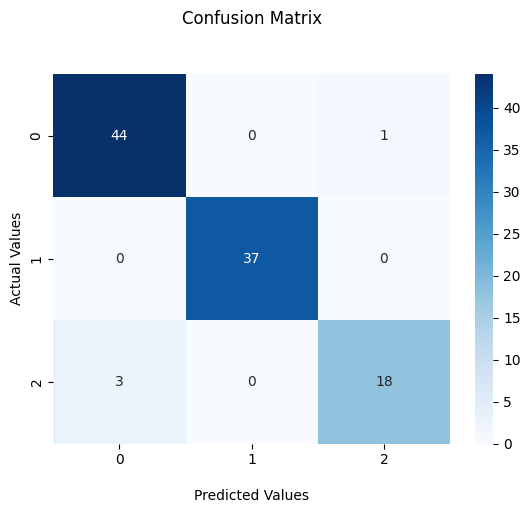

Model Voting


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



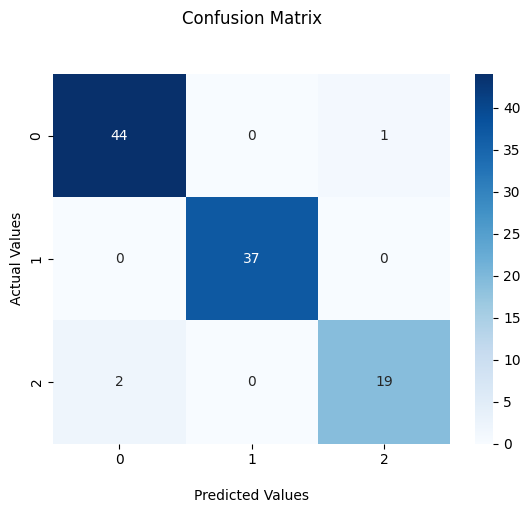

In [8]:
knn_model = best_models['KNN']
knn_model.fit(X_train,y_train)
calculate_metrics(knn_model,'KNN',X_test,y_test)

dtr_model = best_models['Decision Tree']
dtr_model.fit(X_train,y_train)
calculate_metrics(dtr_model,'DecisionTreeClassifier',X_test,y_test)

rfr_model = best_models['Random Forest']
rfr_model.fit(X_train,y_train)
calculate_metrics(rfr_model,'RandomForestClassifier',X_test,y_test)

svc_model = best_models['SVC']
svc_model.set_params(probability=True)
svc_model.fit(X_train,y_train)
calculate_metrics(svc_model,'SVC',X_test,y_test)

ada_model = best_models['AdaBoost']
ada_model.fit(X_train,y_train)
calculate_metrics(ada_model,'AdaBoostClassifier',X_test,y_test)

model_voting = VotingClassifier(estimators=[('Tree', dtr_model),
                                            ('Random Forest', rfr_model),
                                            ('AdaBoost', ada_model),
                                            ('SVC',svc_model),
                                            ('KNN',knn_model)
                                            ],
                                voting='soft')

print('Model Voting')
model_voting.fit(X_train, y_train)
metrics_dataframe = calculate_metrics(model_voting,'Model Voting',X_test,y_test)

Dodanie do zadania PCA:

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze n_components: 0.99
Najlepszy F1 macro CV: 1.0
Logistic Regression z PCA
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



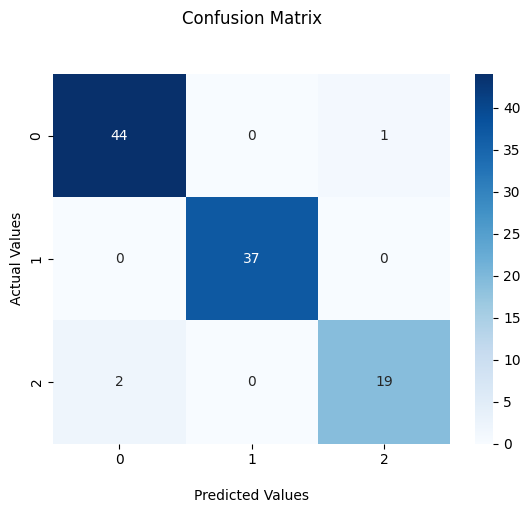

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze n_components: 0.9
Najlepszy F1 macro CV: 0.9949408404732761
KNN z PCA
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        45
           1       1.00      1.00      1.00        37
           2       0.91      1.00      0.95        21

    accuracy                           0.98       103
   macro avg       0.97      0.99      0.98       103
weighted avg       0.98      0.98      0.98       103



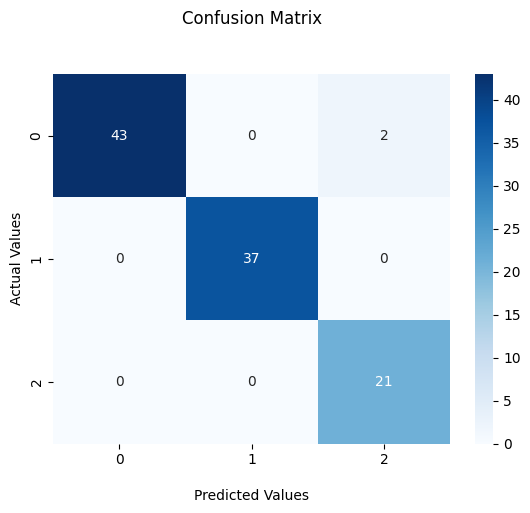

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze n_components: None
Najlepszy F1 macro CV: 0.9446676627283846
Decision Tree z PCA
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



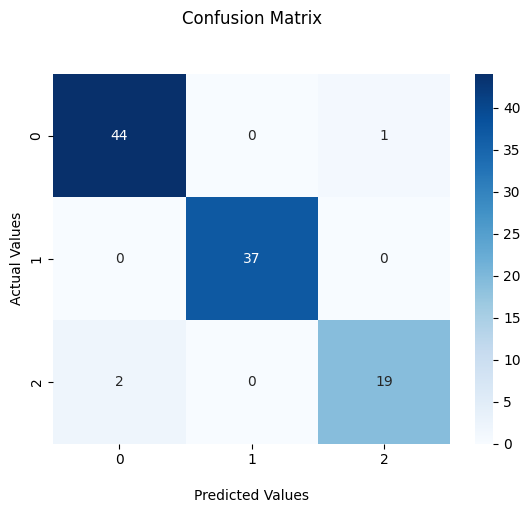

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze n_components: 0.9
Najlepszy F1 macro CV: 0.9630635910756868
Random Forest z PCA
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      1.00      1.00        37
           2       1.00      0.95      0.98        21

    accuracy                           0.99       103
   macro avg       0.99      0.98      0.99       103
weighted avg       0.99      0.99      0.99       103



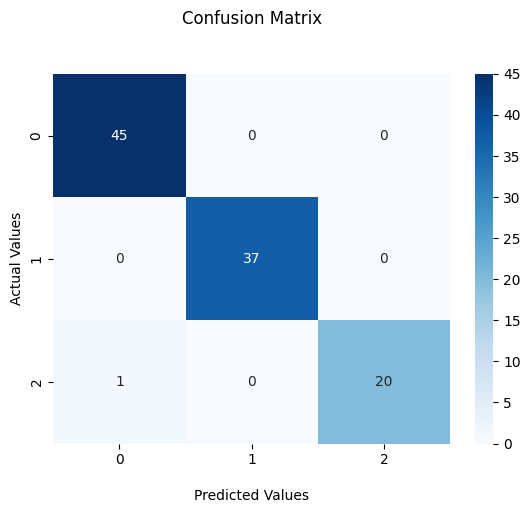

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze n_components: 0.99
Najlepszy F1 macro CV: 0.9901402210385104
SVC z PCA
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


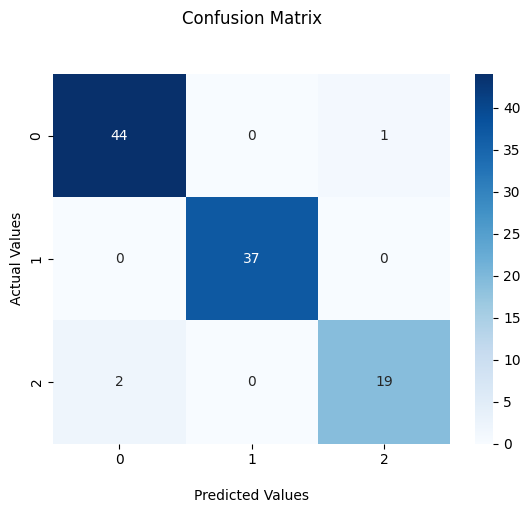

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze n_components: 0.9
Najlepszy F1 macro CV: 0.9573061666588918
AdaBoost z PCA
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        45
           1       1.00      1.00      1.00        37
           2       1.00      0.90      0.95        21

    accuracy                           0.98       103
   macro avg       0.99      0.97      0.98       103
weighted avg       0.98      0.98      0.98       103



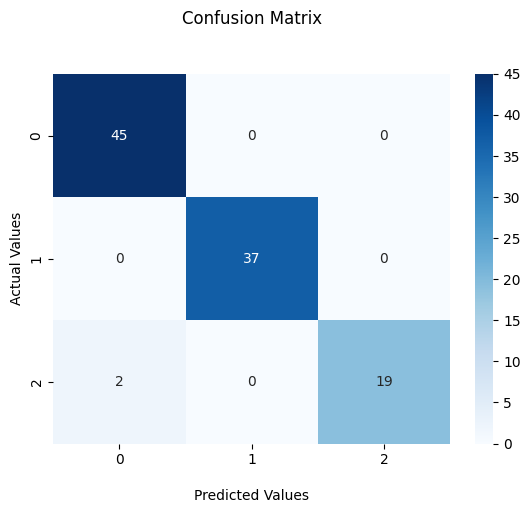

,Model,F1_score
0,KNN,0.980583
1,DecisionTreeClassifier,0.951657
2,RandomForestClassifier,0.960616
3,SVC,0.970679
4,AdaBoostClassifier,0.960616
5,Model Voting,0.970679
6,Logistic Regression z PCA,0.970679
7,KNN z PCA,0.980803
8,Decision Tree z PCA,0.970679
9,Random Forest z PCA,0.990226


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

pca_components = [0.80,0.90,0.95,0.99,None]

best_pca_models = {}
pca_grid_results = {}

for name, model in best_models.items():

    if name == "SVC":
        model.set_params(probability=True)

    pca_pipeline = Pipeline([
        ("pca", PCA(random_state=1)),
        ("classifier", model)
    ])

    pca_params = {"pca__n_components": pca_components}
    pca_grid = GridSearchCV(
        estimator=pca_pipeline,
        param_grid=pca_params,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    pca_grid.fit(X_train, y_train)
    best_pca_model = pca_grid.best_estimator_
    best_pca_models[name] = best_pca_model
    pca_grid_results[name] = pca_grid

    print("Najlepsze n_components:",pca_grid.best_params_["pca__n_components"])
    print("Najlepszy F1 macro CV:",pca_grid.best_score_)

    print(f'{name} z PCA')

    metrics_dataframe.add(calculate_metrics(best_pca_model,f'{name} z PCA',X_test,y_test))

display(metrics_dataframe)

Zastosowanie PCA nie pogorszyło wyników żadnego z analizowanych modeli. Największą poprawę zaobserwowano dla Random Forest, którego F1 wzrosło z 0,961 do 0,990. Poprawiły się również wyniki Decision Tree oraz AdaBoost. Dla KNN zmiana była minimalna, natomiast wynik SVC pozostał bez zmian. Oznacza to, że wpływ PCA zależy od zastosowanego algorytmu i w tym zbiorze największą korzyść przyniosło modelom typu tree.